# Installing the necessary libraries and loading data into datasets

In [2]:
import shutil
shutil.unpack_archive('maternal-health-and-high-risk-pregnancy-dataset.zip', 'mh1')

import pandas as pd
df1= pd.read_excel('mh1/Book2.xlsx')

1. df1 is `binary classification`(IsAtRisk)

In [3]:
print(df1.columns, df1.loc[0].values, sep='\n')
df1 = df1.rename(columns = dict(zip(df1.columns, df1.loc[0].tolist())))

# Comprehensive mapping for our dataset columns to English equivalents
column_mapping = {
    'Name': 'Name',
    'Age': 'Age',
    'Gravida': 'Gravida',
    'TiTi Tika': 'TT_Vaccine',
    'গর্ভকাল': 'GestationalAge',          
    'ওজন': 'Weight',
    'উচ্চতা': 'Height',
    'রক্ত চাপ': 'BloodPressure',         
    'রক্তস্বল্পতা': 'Anemia',
    'জন্ডিস': 'Jaundice',
    'গর্ভস্হ শিশু অবস্থান': 'FetalPosition',
    'গর্ভস্হ শিশু নাড়াচাড়া': 'FetalMovement',
    'গর্ভস্হ শিশু হৃৎস্পন্দন': 'FetalHeartRate', 
    'প্রসাব পরিক্ষা এলবুমিন': 'Urine_Albumin',
    'প্রসাব পরিক্ষা সুগার': 'Urine_Sugar',  
    'VDRL': 'VDRL',
    'HRsAG': 'HBsAg',                     # Correcting typo from HRsAG to HBsAg
    'ঝুকিপূর্ণ গর্ভ': 'IsAtRisk'         # Target
}

# Let's apply the renaming to df1
df1 = df1.rename(columns=column_mapping)
df1 = df1.drop(0, axis=0)

Index(['ANCC REGISTER', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17'],
      dtype='object')
['Name' 'Age' 'Gravida' 'TiTi Tika' 'গর্ভকাল' 'ওজন' 'উচ্চতা' 'রক্ত চাপ'
 'রক্তস্বল্পতা' 'জন্ডিস' 'গর্ভস্হ শিশু অবস্থান' 'গর্ভস্হ শিশু নাড়াচাড়া'
 'গর্ভস্হ শিশু হৃৎস্পন্দন' 'প্রসাব পরিক্ষা এলবুমিন' 'প্রসাব পরিক্ষা সুগার'
 'VDRL' 'HRsAG' 'ঝুকিপূর্ণ গর্ভ']


# Data clean-up and preprocessing

In [4]:
df1.isna().sum()

Name                0
Age                 0
Gravida             0
TT_Vaccine          0
GestationalAge      0
Weight              0
Height              0
BloodPressure       0
Anemia            875
Jaundice          986
FetalPosition       0
FetalMovement       0
FetalHeartRate      0
Urine_Albumin     864
Urine_Sugar         0
VDRL                0
HBsAg               0
IsAtRisk            0
dtype: int64

In [5]:
df1.head()

,Name,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,Rituporna,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
2,Moina,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
3,Rabeya,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes
4,Shorna,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,Yes
5,Tania Akter,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,Normal,125m,NaN,Yes,Negative,Negative,No


In [6]:
df1 = df1.drop(columns = ['Name'])
df1.head()

,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
2,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
3,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes
4,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,Yes
5,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,Normal,125m,NaN,Yes,Negative,Negative,No


In [7]:
import pandas as pd
import numpy as np

def clean_maternal_data(df):
    df = df.copy()
    df['GestationalAge_weeks'] = df['GestationalAge'].str.extract(r'(\d+)').astype(int)
    df['FetalHeartRate'] = df['FetalHeartRate'].str.extract(r'(\d+)').astype(float)
    df['Weight_kg'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)
    
    def height_to_meters(h):
        if pd.isna(h):
            return np.nan
        try:
            h_str = str(h).replace("''", "").strip()
            if '.' in h_str:
                feet = float(h_str.split('.')[0])
                inches = float(h_str.split('.')[1])
            else:
                feet = float(h_str)
                inches = 0
            total_inches = feet * 12 + inches
            return round(total_inches * 0.0254, 4)
        except:
            return np.nan
            
    df['Height_m'] = df['Height'].apply(height_to_meters)
    df[['Systolic', 'Diastolic']] = df['BloodPressure'].str.split('/', expand=True)
    df['Systolic'] = pd.to_numeric(df['Systolic'], errors='coerce')
    df['Diastolic'] = pd.to_numeric(df['Diastolic'], errors='coerce')
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

    cols_to_drop = ['GestationalAge', 'Weight', 'Height', 'BloodPressure']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    
    return df

df1_clean = clean_maternal_data(df1)

print("Shape:", df1_clean.shape)
display(df1_clean.head())

Shape: (998, 18)


,Age,Gravida,TT_Vaccine,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk,GestationalAge_weeks,Weight_kg,Height_m,Systolic,Diastolic
1,18,1st,1st,NaN,NaN,Normal,Normal,140.0,NaN,Yes,Negative,Negative,Yes,38,50.0,1.6002,100,60
2,25,2nd,2nd,NaN,NaN,Normal,Normal,130.0,NaN,Yes,Positive,Negative,No,38,60.0,1.5748,100,70
3,20,1st,1st,NaN,NaN,Normal,Normal,120.0,NaN,Yes,Negative,Negative,Yes,30,55.0,1.5240,100,60
4,22,1st,3rd,NaN,NaN,Normal,Normal,130.0,NaN,Yes,Positive,Negative,Yes,35,51.0,1.6256,110,65
5,20,1st,2nd,NaN,NaN,Normal,Normal,125.0,NaN,Yes,Negative,Negative,No,30,53.0,1.5748,100,55


# Preparing dataset for train and evaluation purpose: 90:10 split

In [8]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier

df1_train, df1_test = train_test_split(df1_clean, test_size=0.1, random_state=1087)

In [9]:
df1_train.describe(include='all')

,Age,Gravida,TT_Vaccine,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk,GestationalAge_weeks,Weight_kg,Height_m,Systolic,Diastolic
count,898.000000,898,898,117,10,898,898,898.000000,120,898,898,898,898,898.000000,898.000000,898.000000,898.000000,898.000000
unique,NaN,3,3,2,2,2,1,NaN,3,2,2,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,1st,2nd,Minimal,Minimal,Normal,Normal,NaN,Medium,Yes,Negative,Negative,Yes,NaN,NaN,NaN,NaN,NaN
freq,NaN,756,410,59,6,893,898,NaN,43,799,451,799,598,NaN,NaN,NaN,NaN,NaN
mean,22.928731,NaN,NaN,NaN,NaN,NaN,NaN,132.154788,NaN,NaN,NaN,NaN,NaN,28.885301,56.093541,1.587585,102.783964,64.599109
std,3.569260,NaN,NaN,NaN,NaN,NaN,NaN,8.774106,NaN,NaN,NaN,NaN,NaN,4.983718,5.353308,0.041274,9.243401,7.975414
min,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,120.000000,NaN,NaN,NaN,NaN,NaN,20.000000,45.000000,1.524000,80.000000,55.000000
25%,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,125.000000,NaN,NaN,NaN,NaN,NaN,25.000000,52.000000,1.549400,100.000000,60.000000
50%,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,NaN,NaN,NaN,NaN,30.000000,56.000000,1.600200,100.000000,60.000000
75%,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,140.000000,NaN,NaN,NaN,NaN,NaN,32.000000,61.000000,1.625600,110.000000,70.000000


# Using VIF score to calculate multi-colinearity amongst features

In [10]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def vif(X):
    X = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_data

In [11]:
df1_train

,Age,Gravida,TT_Vaccine,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk,GestationalAge_weeks,Weight_kg,Height_m,Systolic,Diastolic
578,20,1st,2nd,NaN,NaN,Normal,Normal,130.0,NaN,Yes,Positive,Negative,No,25,62.0,1.5494,100,70
95,24,1st,3rd,NaN,NaN,Normal,Normal,150.0,Medium,Yes,Negative,Negative,No,32,60.0,1.5748,80,60
30,32,2nd,1st,NaN,NaN,Normal,Normal,140.0,NaN,Yes,Positive,Negative,Yes,25,55.0,1.6256,100,65
798,23,1st,1st,NaN,NaN,Normal,Normal,130.0,NaN,Yes,Positive,Positive,Yes,24,65.0,1.6002,100,65
377,20,1st,2nd,NaN,NaN,Normal,Normal,120.0,NaN,Yes,Negative,Negative,No,30,63.0,1.6256,110,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,30,1st,3rd,NaN,NaN,Normal,Normal,120.0,NaN,Yes,Positive,Negative,No,35,63.0,1.6256,110,60
393,24,1st,2nd,NaN,NaN,Normal,Normal,140.0,NaN,Yes,Negative,Positive,Yes,30,65.0,1.5240,90,60
573,19,1st,2nd,Medium,NaN,Normal,Normal,140.0,NaN,Yes,Negative,Positive,Yes,35,61.0,1.6002,110,80
308,24,2nd,3rd,NaN,NaN,Normal,Normal,120.0,NaN,Yes,Positive,Negative,No,28,62.0,1.6002,110,60


In [12]:
from sklearn.preprocessing import LabelEncoder

for col in df1_train.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df1_train[col] = le.fit_transform(df1_train[col])
    df1_test[col] = le.transform(df1_test[col]) 

In [13]:
df1_train

,Age,Gravida,TT_Vaccine,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk,GestationalAge_weeks,Weight_kg,Height_m,Systolic,Diastolic
578,20,0,1,2,2,1,0,130.0,3,1,1,0,0,25,62.0,1.5494,100,70
95,24,0,2,2,2,1,0,150.0,1,1,0,0,0,32,60.0,1.5748,80,60
30,32,1,0,2,2,1,0,140.0,3,1,1,0,1,25,55.0,1.6256,100,65
798,23,0,0,2,2,1,0,130.0,3,1,1,1,1,24,65.0,1.6002,100,65
377,20,0,1,2,2,1,0,120.0,3,1,0,0,0,30,63.0,1.6256,110,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,30,0,2,2,2,1,0,120.0,3,1,1,0,0,35,63.0,1.6256,110,60
393,24,0,1,2,2,1,0,140.0,3,1,0,1,1,30,65.0,1.5240,90,60
573,19,0,1,0,2,1,0,140.0,3,1,0,1,1,35,61.0,1.6002,110,80
308,24,1,2,2,2,1,0,120.0,3,1,1,0,0,28,62.0,1.6002,110,60


In [14]:
vif(df1_train.drop('IsAtRisk', axis=1))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Feature,VIF
0,const,2560.056158
1,Age,1.065423
2,Gravida,1.049952
3,TT_Vaccine,1.105142
4,Anemia,1.011663
5,Jaundice,1.025878
6,FetalPosition,1.008608
7,FetalMovement,NaN
8,FetalHeartRate,1.003042
9,Urine_Albumin,1.012454


In [15]:
df1_train = df1_train.drop(columns = ['FetalMovement'])
df1_test = df1_test.drop(columns = ['FetalMovement'])
df1_train.head()

,Age,Gravida,TT_Vaccine,Anemia,Jaundice,FetalPosition,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk,GestationalAge_weeks,Weight_kg,Height_m,Systolic,Diastolic
578,20,0,1,2,2,1,130.0,3,1,1,0,0,25,62.0,1.5494,100,70
95,24,0,2,2,2,1,150.0,1,1,0,0,0,32,60.0,1.5748,80,60
30,32,1,0,2,2,1,140.0,3,1,1,0,1,25,55.0,1.6256,100,65
798,23,0,0,2,2,1,130.0,3,1,1,1,1,24,65.0,1.6002,100,65
377,20,0,1,2,2,1,120.0,3,1,0,0,0,30,63.0,1.6256,110,80


# Feature Correlation heatmap plotting

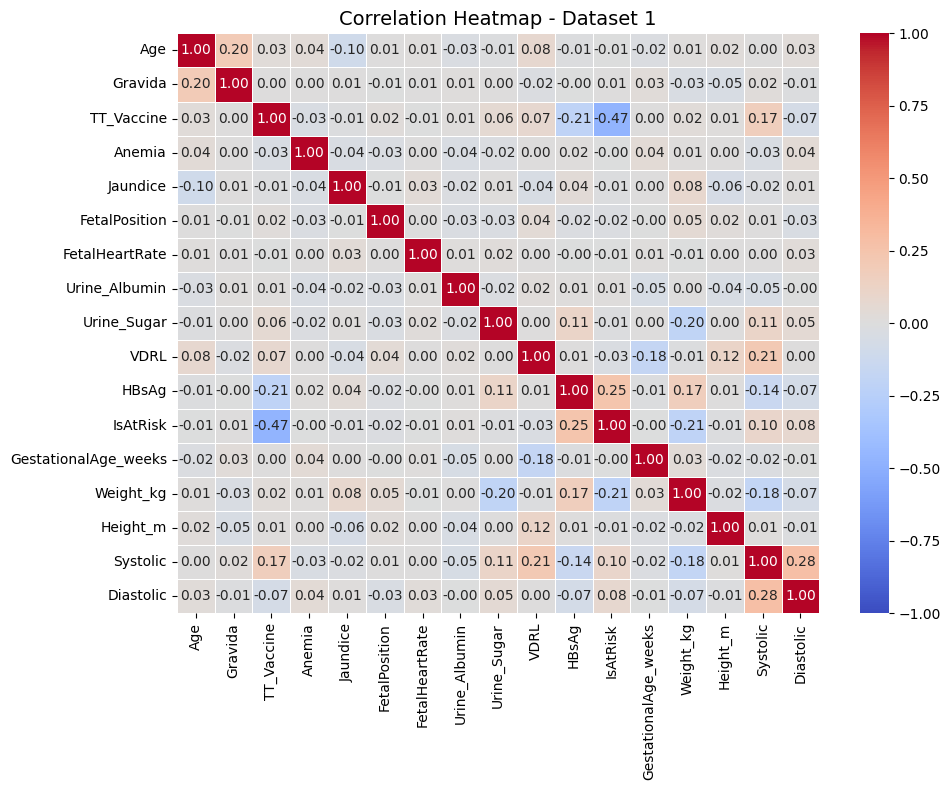

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_df1 = df1_train.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_df1, 
    annot=True,         
    cmap="coolwarm",    
    fmt=".2f",           
    linewidths=0.5,     
    vmin=-1, vmax=1     
)

plt.title("Correlation Heatmap - Dataset 1", fontsize=14)
plt.tight_layout()
plt.show()

# Using DBSCAN algorithm to find outliers

In [17]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler as SS

scalers = SS()
scaled_datas = scalers.fit_transform(df1_train.copy())

dbscan = DBSCAN(eps=3.0, min_samples=20)
clusters = dbscan.fit_predict(scaled_datas)
df1_train['Cluster'] = clusters
print("Total no of Outliers in this dataset:   ", (df1_train["Cluster"] == -1).sum())

Total no of Outliers in this dataset:    287


# Removing outliers on Dataset1 based on clustering

In [18]:
print(len(df1_train))
df1_train = df1_train[df1_train["Cluster"] != -1]
print(len(df1_train))

898
611


In [19]:
print(df1_train["IsAtRisk"].value_counts())

IsAtRisk
1    408
0    203
Name: count, dtype: int64


In [20]:
df1_train = df1_train.drop("Cluster", axis = 1)

In [21]:
df1_train.head()

,Age,Gravida,TT_Vaccine,Anemia,Jaundice,FetalPosition,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk,GestationalAge_weeks,Weight_kg,Height_m,Systolic,Diastolic
578,20,0,1,2,2,1,130.0,3,1,1,0,0,25,62.0,1.5494,100,70
798,23,0,0,2,2,1,130.0,3,1,1,1,1,24,65.0,1.6002,100,65
377,20,0,1,2,2,1,120.0,3,1,0,0,0,30,63.0,1.6256,110,80
955,23,0,1,2,2,1,140.0,3,1,0,0,1,35,61.0,1.5748,100,70
251,20,0,0,2,2,1,140.0,1,1,0,0,0,30,52.0,1.5748,100,70


# 5-fold Cross-validation on Dataset1 using XGBoost and GridSearchCV

In [22]:
import warnings

X_train1 = df1_train.drop(columns=["IsAtRisk"])
y_train1 = df1_train["IsAtRisk"]

clf = XGBClassifier(
    device='cuda',
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')
    grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train1, y_train1)

joblib.dump(grid_search.best_estimator_, 'model1.pkl')
print("Model1 saved to model1.pkl")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:20:12] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:20:12] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

Model1 saved to model1.pkl


In [23]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
print("Best n_estimators:", best_model.n_estimators)
print("Best max_depth:",    best_model.max_depth)
print("Best learning_rate:", best_model.learning_rate)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best n_estimators: 300
Best max_depth: 3
Best learning_rate: 0.1


In [ ]:
df1_test.to_csv('test1.csv', index=False)